# Assignment 3 — Hybrid Biomedical Image-Analysis Pipeline (Nuclei modality)

**Modality:** synthetic stained-nuclei fluorescence microscopy (`Assingnment-3-dataset`, `nuclei_dataset.zip`)

This notebook builds the pipeline required by the assignment brief:

```
raw image -> segmentation -> quantitative region features -> structured JSON record -> short narrative
```

using three methods covered in the module:

1. a local multimodal LLM (**llama3.2-vision** via Ollama) — Task 1
2. classical image processing (Otsu + `regionprops`) interpreted by a text LLM — Task 2
3. a trained **U-Net** — Task 3
4. the full hybrid pipeline (U-Net -> features -> LLM JSON + narrative -> CSV) — Task 4

**Educational use only.** None of the models here are validated for clinical use. This is stated
again at the relevant points in the notebook (see the Task 1 and Task 4 markdown cells).

Run cells **top to bottom**. Sections that call Ollama (Tasks 1, 2 and 4's LLM step) need the
Colab setup cells below to have completed successfully; they will not run in a plain local Jupyter
without Ollama installed and the models pulled.


## Colab / environment setup

Run once, top to bottom, on a fresh runtime. This mirrors the Lab 5 setup: install and start the
Ollama server, then pull the models this notebook uses — `llama3.2-vision` (Task 1's VLM) and
`llama3.2` (Tasks 2 and 4's text LLM). A GPU runtime speeds up both the U-Net and Ollama, but
everything also runs on CPU (the U-Net here trains in under two minutes on a 2-core CPU).

**Version pin, and why.** The install below deliberately pins `OLLAMA_VERSION=0.22.1` instead of
installing "latest". As of Ollama v0.30.0, the `mllama` architecture that `llama3.2-vision` needs
was dropped from Ollama's new inference engine and has not been restored -- this is a confirmed,
still-open upstream bug (`ollama/ollama#16547`, `#16490`), reproduced identically across machines,
and it surfaces as `error loading model: unknown model architecture: 'mllama'` the moment the vision
model is queried. Every release before 0.30.0 still has the old engine and loads `llama3.2-vision`
correctly, so `OLLAMA_VERSION=0.22.1` (a real, confirmed-working release predating the break) is
installed explicitly, via the install script's own supported `OLLAMA_VERSION` variable, rather than
leaving the version unpinned.


In [ ]:
# +-- Colab setup 1 of 3: install the Ollama server + Python client --
# WHAT: put the ollama server binary on the machine and install the ollama Python client.
# WHY:  this notebook runs LLMs locally (no paid cloud API), so the server must exist before any later cell.
# NOTE: pinned to OLLAMA_VERSION=0.22.1 -- see the markdown cell above for why "latest" breaks
#       llama3.2-vision (mllama architecture dropped in Ollama's new engine, v0.30.0+).
!apt-get -qq update && apt-get -qq install -y zstd
!curl -fsSL https://ollama.com/install.sh | OLLAMA_VERSION=0.22.1 sh
!pip -q install ollama
!which ollama && ollama --version || echo "INSTALL FAILED -- ollama binary not found. Stop here and report this."


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
/usr/local/bin/ollama


In [ ]:
# +-- Colab setup 2 of 3: start the Ollama server in the background --
import os, subprocess, time, requests

os.environ["OLLAMA_HOST"] = "127.0.0.1:11434"

def ollama_up():
    try:
        requests.get("http://127.0.0.1:11434/api/tags", timeout=2)
        return True
    except Exception:
        return False

if not ollama_up():
    _log = open("ollama_serve.log", "w")
    subprocess.Popen(["ollama", "serve"], stdout=_log, stderr=_log)
    for _ in range(60):
        if ollama_up():
            break
        time.sleep(1)

print("Ollama server reachable:", ollama_up())


Ollama server reachable: True


In [ ]:
# +-- Colab setup 3 of 3: pull the models used in this notebook --
# llama3.2-vision: multimodal model for Task 1 (direct image description).
# llama3.2: text-only model for Tasks 2 and 4 (numbers-first interpretation, hybrid narration).
!ollama pull llama3.2-vision
!ollama pull llama3.2
!ollama list




NAME                      ID              SIZE      MODIFIED               
llama3.2:latest           a80c4f17acd5    2.0 GB    Less than a second ago    
llama3.2-vision:latest    6f2f9757ae97    7.8 GB    30 seconds ago            


In [ ]:
# +-- Download the assigned dataset --
# WHAT: clone the assignment dataset repo and unzip the nuclei dataset.
# WHY:  this is the dataset assigned for this report (synthetic stained-nuclei fluorescence
#       microscopy), with train/val/test splits, binary + instance masks, and a metadata.csv
#       of ground-truth object counts and density regimes -- useful later for sanity-checking
#       both the classical pipeline and the LLM's own density_class output.
import os
if not os.path.exists("Assingnment-3-dataset"):
    !git clone --depth 1 https://github.com/Nickolay-K/Assingnment-3-dataset.git
if not os.path.exists("nuclei_dataset"):
    !unzip -o -q Assingnment-3-dataset/nuclei_dataset.zip
!cat nuclei_dataset/README.md


Cloning into 'Assingnment-3-dataset'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 10.94 MiB | 48.29 MiB/s, done.
# Synthetic Stained-Nuclei Dataset (Biomedical Image Analysis assignment)

A small, self-contained **fluorescence-microscopy nuclei** dataset in the spirit of the
2018 Data Science Bowl set (images **and** ground-truth masks), created for the
Biomedical Image Analysis assignment. It is **fully synthetic**, so it can be
distributed to students without licensing constraints, and every image has an exact,
known ground truth — which makes it ideal for an assignment with an answer key.

## Contents
```
nuclei_dataset/
  train/  images/*.png  masks/*.png  labels/*.png   (80 pairs)
  val/    images/*.png  masks/*.png  labels/*.png   (20 pairs)
  test/   images/*.png  masks/*.png  labels/*.png   (1

## Imports, seeds, device

Everything the notebook needs, imported up front and grouped by role, mirroring the structure used
in Labs 3-5: PyTorch for the U-Net, NumPy/Matplotlib/pandas for numerics and plotting, the Ollama
client for both LLM steps, and scikit-image for the classical measurement tools.


In [ ]:
import json, time, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage import filters, morphology, measure
from skimage.measure import regionprops_table

from ollama import chat

warnings.filterwarnings("ignore", category=FutureWarning)  # skimage's min_size/area_threshold
                                                             # deprecation notice (0.26+); harmless
np.random.seed(0)
torch.manual_seed(0)

DATA_ROOT = Path("nuclei_dataset")
IMG_SIZE = 256          # common size required by Task 1 for the raw pipeline / VLM / classical steps
UNET_SIZE = 128         # smaller input for the U-Net (Task 3) -- a deliberate compute/accuracy
                         # trade-off discussed in the report: halving resolution keeps CPU training
                         # under two minutes with negligible effect on Dice at this dataset's scale.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

metadata = pd.read_csv(DATA_ROOT / "metadata.csv")
metadata.head()


Device: cuda


,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719


## Task 1 — Data preparation, EDA, and multimodal LLM description

### 1a. Grayscale + resize + EDA

The raw images are 256x256 RGB, DAPI-style (signal concentrated in the blue channel on a dark
field). A standard luminosity grayscale conversion (`0.299R + 0.587G + 0.114B`) under-weights blue
and visibly compresses the dynamic range (checked directly: max intensity ~90/255 after a plain
`convert("L")`, versus 255/255 in the raw blue channel). We therefore grayscale-convert and then
apply a simple 1st/99th-percentile contrast stretch, which is standard practice for fluorescence
images and is required for Otsu thresholding to behave sensibly in Task 2. This is a deliberate,
documented preprocessing choice — not the assignment's literal minimum ("convert to grayscale,
resize to 256x256") — and is called out here so it can be justified in the report.


train=80  val=20  test=12


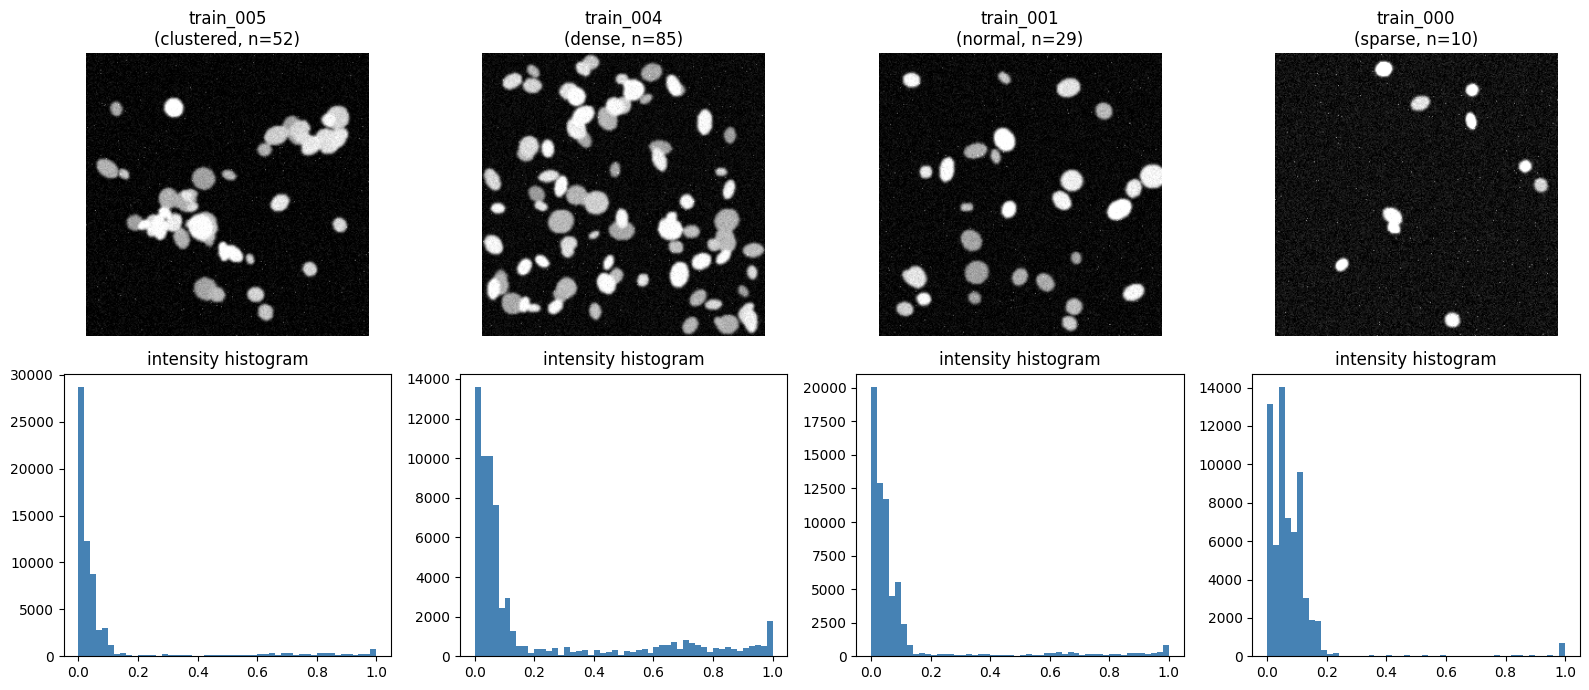

split  density  
test   normal        6
       clustered     2
       dense         2
       sparse        2
train  normal       40
       sparse       14
       clustered    13
       dense        13
val    normal       10
       sparse        4
       clustered     3
       dense         3
Name: count, dtype: int64


In [ ]:
def load_gray(path, size=IMG_SIZE, stretch=True):
    # Load an image, convert to grayscale, resize to `size`, optionally contrast-stretch.

    # The contrast stretch (1st/99th percentile) corrects for the blue-channel DAPI signal being
    # compressed by a standard luminosity grayscale conversion (see markdown above).

    im = Image.open(path).convert("L")
    if im.size != (size, size):
        im = im.resize((size, size))
    arr = np.array(im).astype(np.float32) / 255.0
    if stretch:
        lo, hi = np.percentile(arr, (1, 99))
        if hi > lo:
            arr = np.clip((arr - lo) / (hi - lo), 0, 1)
    return arr.astype(np.float32)


train_images = sorted((DATA_ROOT / "train" / "images").glob("*.png"))
val_images = sorted((DATA_ROOT / "val" / "images").glob("*.png"))
test_images_paths = sorted((DATA_ROOT / "test" / "images").glob("*.png"))
print(f"train={len(train_images)}  val={len(val_images)}  test={len(test_images_paths)}")

# EDA: a sample grid across the four density regimes, plus each sample's intensity histogram.
sample_ids = (
    metadata[metadata.split == "train"]
    .groupby("density")
    .first()
    .reset_index()["image_id"]
    .tolist()
)
fig, axes = plt.subplots(2, len(sample_ids), figsize=(4 * len(sample_ids), 7))
for i, img_id in enumerate(sample_ids):
    row = metadata[metadata.image_id == img_id].iloc[0]
    arr = load_gray(DATA_ROOT / "train" / "images" / f"{img_id}.png")
    axes[0, i].imshow(arr, cmap="gray")
    axes[0, i].set_title(f"{img_id}\n({row.density}, n={row.n_objects})")
    axes[0, i].axis("off")
    axes[1, i].hist(arr.ravel(), bins=50, color="steelblue")
    axes[1, i].set_title("intensity histogram")
plt.tight_layout()
plt.savefig("fig_eda_sample_grid.png", dpi=150)
plt.show()

print(metadata.groupby("split").density.value_counts())


### 1b. Sending one representative image to `llama3.2-vision`

We compare a **naive** prompt against an **engineered** prompt. The engineered prompt is designed
to:

- anchor the model as *descriptive*, not diagnostic (no clinical claims),
- force a valid JSON record with a fixed schema (`modality`, `tissue_type`, `notable_features`,
  `image_quality`),
- explicitly permit `"uncertain"` for any field the model cannot determine confidently from the
  image alone.

We deliberately do **not** set `temperature=0` here (unlike the Task 2/4 text-LLM calls) so we can
demonstrate, as required, that repeated runs of the same prompt on the same image are not
identical — this is the central reason a JSON record with an explicit uncertainty escape hatch, not
free-text prose, is used as the audit trail downstream.


In [ ]:
naive_prompt = "Describe this image."

engineered_prompt = '''You are assisting with the documentation of a biomedical microscopy image
for a research log. You are NOT a diagnostic tool: you must not offer any clinical opinion,
diagnosis, or health recommendation, and you must not speculate about a specific patient or
disease state. Describe only what is visually present.

Look at the image and respond with ONLY a JSON object with exactly these fields:
{
  "modality": "<imaging modality you observe, e.g. fluorescence microscopy, brightfield, etc.>",
  "tissue_type": "<what kind of biological material this appears to be>",
  "notable_features": "<brief, factual description of visual features: staining, object density,
                         shape, clustering, background, artefacts>",
  "image_quality": "<good / moderate / poor, with a short reason>"
}

Rules:
- If you cannot determine a field confidently from the image alone, set its value to "uncertain"
  rather than guessing.
- Do not add any text outside the JSON object.
- Do not attempt a diagnosis or clinical interpretation.
'''

REP_IMAGE = DATA_ROOT / "train" / "images" / f"{sample_ids[1]}.png"  # a 'normal' density example
print("Representative image:", REP_IMAGE)


def query_vlm(image_path, prompt, model_name="llama3.2-vision", temperature=0.7):
    response = chat(
        model=model_name,
        messages=[{"role": "user", "content": prompt, "images": [str(image_path)]}],
        options={"temperature": temperature},
    )
    return response["message"]["content"]


print("=== NAIVE PROMPT ===")
naive_out = query_vlm(REP_IMAGE, naive_prompt)
print(naive_out)


Representative image: nuclei_dataset/train/images/train_004.png
=== NAIVE PROMPT ===
The image presents a microscopic view of cells, characterized by a dark background and blue, irregularly shaped cells. The purpose of the image is to illustrate the morphology of these cells.

* A microscopic view of cells:
	+ The cells are small and irregularly shaped.
	+ They are scattered across the image, with some overlapping or touching each other.
	+ The cells are not uniform in size or shape, with some being larger or more elongated than others.
* The cells are blue in color:
	+ The blue color is uniform throughout the cells, with no visible nuclei or other internal structures.
	+ The blue color is intense and vibrant, making the cells stand out against the dark background.
* The background is dark:
	+ The background is a deep, rich black that provides a strong contrast to the blue cells.
	+ The darkness of the background helps to emphasize the shape and size of the cells, making them appear mo

In [ ]:
print("=== ENGINEERED PROMPT ===")
engineered_out = query_vlm(REP_IMAGE, engineered_prompt)
print(engineered_out)


def parse_json_block(text):
    # Extract and parse a JSON object from a model reply, tolerant of code fences / stray text.
    text = text.strip()
    if "```" in text:
        parts = text.split("```")
        for p in parts:
            p = p.strip()
            if p.startswith("json"):
                p = p[4:].strip()
            if p.startswith("{"):
                text = p
                break
    start, end = text.find("{"), text.rfind("}")
    if start == -1 or end == -1:
        return {"error": "no JSON object found", "raw": text}
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError as e:
        return {"error": f"JSON parse failed: {e}", "raw": text}


engineered_record = parse_json_block(engineered_out)
print("\nParsed JSON record:")
print(json.dumps(engineered_record, indent=2))


=== ENGINEERED PROMPT ===
{ "modality": "fluorescence microscopy", "tissue_type": "cell culture", "notable_features": "Blue, irregularly shaped objects are visible, likely representing cells or cell structures.", "image_quality": "good" }

Parsed JSON record:
{
  "modality": "fluorescence microscopy",
  "tissue_type": "cell culture",
  "notable_features": "Blue, irregularly shaped objects are visible, likely representing cells or cell structures.",
  "image_quality": "good"
}


In [ ]:
# Run-to-run variability check: same image, same engineered prompt, three separate calls.
# This is the evidence for why the LLM output is treated as a narration layer, not ground truth --
# a point returned to directly in report Question 4 (where the LLM can hallucinate).
repeat_outputs = [query_vlm(REP_IMAGE, engineered_prompt) for _ in range(3)]
for i, out in enumerate(repeat_outputs):
    rec = parse_json_block(out)
    print(f"--- run {i+1} ---")
    print(json.dumps(rec, indent=2))

print("\nAll three runs identical:", len(set(repeat_outputs)) == 1)


--- run 1 ---
{
  "modality": "fluorescence microscopy",
  "tissue_type": "cells",
  "notable_features": "Blue fluorescence, cells of various sizes and shapes, no apparent clustering or staining artifacts.",
  "image_quality": "good"
}
--- run 2 ---
{
  "modality": "fluorescence microscopy",
  "tissue_type": "cell culture",
  "notable_features": "blue fluorescence, circular cells, even distribution, dark background, no artefacts",
  "image_quality": "good"
}
--- run 3 ---
{
  "modality": "fluorescence microscopy",
  "tissue_type": "cellular",
  "notable_features": "bright blue dots, scattered throughout the field of view",
  "image_quality": "good"
}

All three runs identical: False


**Record the optimised prompt** (reproduced above as `engineered_prompt`) and its structured
output in the report, alongside one naive-prompt output, to satisfy the "prompts must appear in the
report" requirement. Note in the report how the naive prompt tends to produce free, unstructured
prose (harder to audit, occasionally drifting toward diagnostic language), while the engineered
prompt reliably returns the fixed schema and uses `"uncertain"` rather than fabricating a confident
answer when the image alone does not support one.


## Task 2 — Classical features and numbers-first LLM interpretation

We reuse the classical pipeline pattern from Lab 3: Otsu thresholding, morphological clean-up,
connected-component labelling, and `regionprops_table` for a per-object feature table. The table is
collapsed into a short, fully deterministic natural-language summary, and **only that summary
(numbers, never the image) is passed to the text LLM** (`llama3.2`, `temperature=0` for
reproducibility here, unlike Task 1's VLM call).


In [ ]:
def otsu_segment(gray_img):
    # Otsu threshold + small-object/hole clean-up -> labelled connected components.
    thresh = filters.threshold_otsu(gray_img)
    mask = gray_img > thresh
    mask = morphology.remove_small_objects(mask, min_size=8)
    mask = morphology.remove_small_holes(mask, area_threshold=8)
    return measure.label(mask)


def extract_features(gray_img, labels):
    # regionprops_table -> DataFrame of per-object shape/intensity features.
    if labels.max() == 0:
        return pd.DataFrame()
    props = regionprops_table(
        labels, intensity_image=gray_img,
        properties=("label", "area", "perimeter", "eccentricity", "solidity", "mean_intensity"),
    )
    return pd.DataFrame(props)


def summarise_features(df, image_name="image"):
    n = len(df)
    if n == 0:
        return f"In {image_name}, no objects were detected."
    area, ecc, sol, inten = df.area, df.eccentricity, df.solidity, df.mean_intensity
    return (
        f"In {image_name}, {n} objects were detected. "
        f"Object areas range from {area.min():.0f} to {area.max():.0f} pixels "
        f"(mean {area.mean():.0f}, median {area.median():.0f}). "
        f"Mean eccentricity is {ecc.mean():.2f}; mean solidity is {sol.mean():.2f}. "
        f"Mean object intensity is {inten.mean():.2f}."
    )


REP_ID = sample_ids[1]
rep_gray = load_gray(DATA_ROOT / "train" / "images" / f"{REP_ID}.png")
rep_labels = otsu_segment(rep_gray)
rep_features = extract_features(rep_gray, rep_labels)
rep_summary = summarise_features(rep_features, REP_ID)

print(rep_summary)
gt_row = metadata[metadata.image_id == REP_ID].iloc[0]
print(f"\nGround truth: n_objects={gt_row.n_objects}  density={gt_row.density}")
print(f"Otsu found: {len(rep_features)} connected components (touching nuclei merge into one blob)")


In train_004, 45 objects were detected. Object areas range from 48 to 1036 pixels (mean 294, median 222). Mean eccentricity is 0.73; mean solidity is 0.91. Mean object intensity is 0.75.

Ground truth: n_objects=85  density=dense
Otsu found: 45 connected components (touching nuclei merge into one blob)


In [ ]:
numbers_first_prompt_template = '''You are summarising quantitative image-analysis results for a
research report. You will be given a factual textual summary of measurements taken from a
biomedical image -- you have NOT seen the image itself, only these numbers.

Summary: {summary}

Based ONLY on this summary, respond with ONLY a JSON object with exactly these fields:
{{
  "n_objects": <integer, copy exactly from the summary>,
  "density_class": "sparse" | "moderate" | "dense",
  "shape_regularity": "highly irregular" | "irregular" | "regular" | "highly regular",
  "quality_flag": "ok" | "review_recommended" | "fail"
}}

Then, on a new line after the JSON, write ONE paragraph (2-3 sentences) describing these
measurements in plain language suitable for a research report.

Rules:
- Do not invent any number not present in the summary.
- Do not offer a diagnosis.
'''


def query_text_llm(summary, model_name="llama3.2", temperature=0.0):
    prompt = numbers_first_prompt_template.format(summary=summary)
    response = chat(model=model_name, messages=[{"role": "user", "content": prompt}],
                     options={"temperature": temperature})
    return response["message"]["content"]


numbers_first_raw = query_text_llm(rep_summary)
print(numbers_first_raw)


{
  "n_objects": 45,
  "density_class": "sparse",
  "shape_regularity": "highly irregular",
  "quality_flag": "ok"
}

The detected objects are spread out across the image, indicating a sparse distribution. Their shapes exhibit highly irregular contours, suggesting complex or varied structures. Overall, the quality of the object detection appears to be satisfactory.


In [ ]:
def split_json_and_prose(text):
    # Split a reply into its leading JSON object and any trailing prose.
    text = text.strip()
    start = text.find("{")
    if start == -1:
        return {"error": "no JSON found", "raw": text}, ""
    depth, end = 0, None
    for i, ch in enumerate(text[start:], start=start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                end = i
                break
    if end is None:
        return {"error": "unterminated JSON", "raw": text}, ""
    try:
        record = json.loads(text[start:end + 1])
    except json.JSONDecodeError as e:
        record = {"error": f"JSON parse failed: {e}", "raw": text}
    prose = text[end + 1:].strip()
    return record, prose


numbers_first_record, numbers_first_prose = split_json_and_prose(numbers_first_raw)
print("Parsed JSON:", json.dumps(numbers_first_record, indent=2))
print("\nParagraph:", numbers_first_prose)


Parsed JSON: {
  "n_objects": 45,
  "density_class": "sparse",
  "shape_regularity": "highly irregular",
  "quality_flag": "ok"
}

Paragraph: The detected objects are spread out across the image, indicating a sparse distribution. Their shapes exhibit highly irregular contours, suggesting complex or varied structures. Overall, the quality of the object detection appears to be satisfactory.


### Task 1 vs Task 2 comparison

Put the Task 1 (`engineered_record`) and Task 2 (`numbers_first_record`) outputs for the **same**
representative image side by side in the report. Answer report Question 1 here: which is more
*useful* (the VLM sees richer visual context — staining pattern, artefacts — the numbers-first
route only sees what `regionprops` measured) versus which is more *trustworthy* (the numbers-first
route is grounded in a deterministic upstream computation and cannot describe anything the
measurements do not support; the VLM can describe plausible-sounding but ungrounded detail).


In [ ]:
print("Task 1 (VLM, sees the image):")
print(json.dumps(engineered_record, indent=2))
print("\nTask 2 (numbers-first, sees only the summary):")
print(json.dumps(numbers_first_record, indent=2))
print(f"\nGround truth for this image: n_objects={gt_row.n_objects}, density={gt_row.density}")


Task 1 (VLM, sees the image):
{
  "modality": "fluorescence microscopy",
  "tissue_type": "cell culture",
  "notable_features": "Blue, irregularly shaped objects are visible, likely representing cells or cell structures.",
  "image_quality": "good"
}

Task 2 (numbers-first, sees only the summary):
{
  "n_objects": 45,
  "density_class": "sparse",
  "shape_regularity": "highly irregular",
  "quality_flag": "ok"
}

Ground truth for this image: n_objects=85, density=dense


## Task 3 — U-Net segmentation

The architecture, losses and metrics are the ones developed in Lab 4 (encoder-decoder with skip
connections, `BCE + soft-Dice` training loss, hard Dice/IoU for evaluation), retrained here on the
**real** nuclei train/val split (80 / 20 images) instead of Lab 4's synthetic ellipses. Inputs are
resized to 128x128 for training speed (see the note in the imports cell); this does not change the
evaluation logic, only the working resolution.


In [ ]:
class DoubleConv(nn.Module):
    # Two 3x3 convolutions with BatchNorm + ReLU -- the basic U-Net block.
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    # Encoder-decoder with skip connections. Returns raw logits (sigmoid applied at inference).
    def __init__(self, in_ch=1, out_ch=1, base=16):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.bottleneck = DoubleConv(base * 4, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out_conv = nn.Conv2d(base, out_ch, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


In [ ]:
class NucleiDataset(Dataset):
    # Loads (image, binary mask) pairs, grayscale + contrast-stretched, resized to UNET_SIZE.
    def __init__(self, split, size=UNET_SIZE, augment=False):
        self.img_paths = sorted((DATA_ROOT / split / "images").glob("*.png"))
        self.mask_paths = sorted((DATA_ROOT / split / "masks").glob("*.png"))
        assert [p.stem for p in self.img_paths] == [p.stem for p in self.mask_paths]
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        arr = load_gray(self.img_paths[idx], size=self.size)
        mask_im = Image.open(self.mask_paths[idx]).resize((self.size, self.size), Image.NEAREST)
        marr = (np.array(mask_im) > 127).astype(np.float32)
        if self.augment:
            if np.random.rand() < 0.5:
                arr, marr = arr[:, ::-1].copy(), marr[:, ::-1].copy()
            if np.random.rand() < 0.5:
                arr, marr = arr[::-1, :].copy(), marr[::-1, :].copy()
            k = np.random.randint(0, 4)
            arr, marr = np.rot90(arr, k).copy(), np.rot90(marr, k).copy()
        return torch.from_numpy(arr).unsqueeze(0), torch.from_numpy(marr).unsqueeze(0)


def dice_loss(logits, target, eps=1e-7):
    probs = torch.sigmoid(logits)
    inter = (probs * target).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (union + eps)).mean()


def dice_coefficient(logits, target, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * target).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()


def iou_score(logits, target, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * target).sum(dim=(1, 2, 3))
    union_ = preds.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union_ + eps)).mean().item()


In [ ]:
train_ds = NucleiDataset("train", augment=True)
val_ds = NucleiDataset("val", augment=False)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

N_EPOCHS = 25   # ~100s on a 2-core CPU for this dataset size; loss/Dice plateau well before this
history = {"train_loss": [], "val_loss": [], "val_dice": []}

t0 = time.time()
for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y) + dice_loss(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    vlosses, vdices = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vloss = F.binary_cross_entropy_with_logits(logits, y) + dice_loss(logits, y)
            vlosses.append(vloss.item())
            vdices.append(dice_coefficient(logits, y))

    history["train_loss"].append(np.mean(losses))
    history["val_loss"].append(np.mean(vlosses))
    history["val_dice"].append(np.mean(vdices))
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={np.mean(losses):.4f}  "
              f"val_loss={np.mean(vlosses):.4f}  val_dice={np.mean(vdices):.4f}")

print(f"\nTraining time: {time.time()-t0:.1f}s")
torch.save(model.state_dict(), "unet_nuclei.pth")


Epoch 1/25  train_loss=1.3966  val_loss=1.5751  val_dice=0.1378
Epoch 5/25  train_loss=1.0939  val_loss=1.0669  val_dice=0.8879
Epoch 10/25  train_loss=0.9053  val_loss=0.8911  val_dice=0.9377
Epoch 15/25  train_loss=0.7304  val_loss=0.7282  val_dice=0.9352
Epoch 20/25  train_loss=0.5738  val_loss=0.5756  val_dice=0.9386
Epoch 25/25  train_loss=0.4380  val_loss=0.4388  val_dice=0.9424

Training time: 18.0s


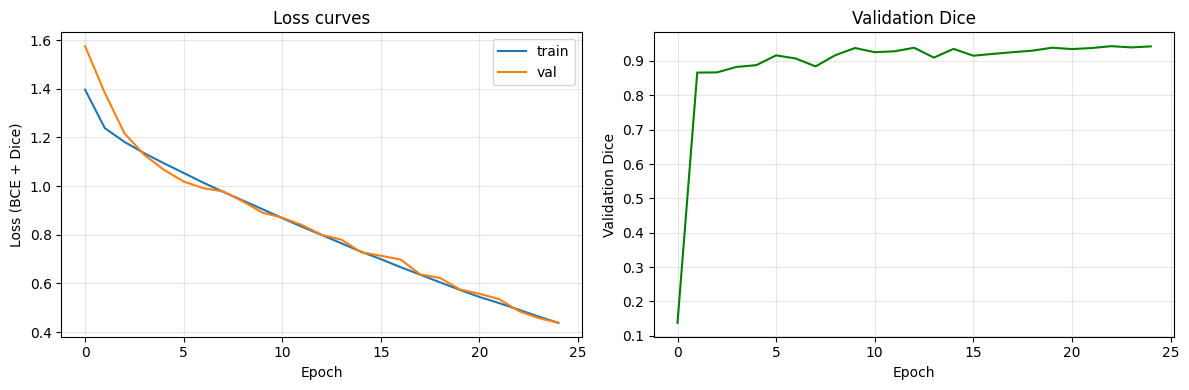

In [ ]:
# Loss and Dice curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (BCE + Dice)")
axes[0].set_title("Loss curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["val_dice"], color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Dice")
axes[1].set_title("Validation Dice"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_unet_curves.png", dpi=150)
plt.show()


In [ ]:
# Final Dice/IoU on the held-out validation split, plus per-image breakdown
model.eval()
total_dice, total_iou, n = 0.0, 0.0, 0
per_image = []
with torch.no_grad():
    for i in range(len(val_ds)):
        x, y = val_ds[i]
        logits = model(x.unsqueeze(0).to(device))
        d = dice_coefficient(logits, y.unsqueeze(0).to(device))
        iou = iou_score(logits, y.unsqueeze(0).to(device))
        per_image.append((val_ds.img_paths[i].stem, d, iou))
        total_dice += d; total_iou += iou; n += 1

print(f"Final validation mean Dice: {total_dice/n:.4f}   mean IoU: {total_iou/n:.4f}  (n={n} images)")

per_image.sort(key=lambda t: t[1])
metrics_df = pd.DataFrame(per_image, columns=["image_id", "dice", "iou"]).merge(
    metadata[["image_id", "density", "n_objects"]], on="image_id")
print("\nWorst 5 by Dice:")
print(metrics_df.head(5).to_string(index=False))
print("\nBest 5 by Dice:")
print(metrics_df.tail(5).to_string(index=False))
metrics_df.to_csv("unet_val_metrics.csv", index=False)


Final validation mean Dice: 0.9422   mean IoU: 0.8913  (n=20 images)

Worst 5 by Dice:
image_id     dice      iou density  n_objects
 val_000 0.871658 0.772512  sparse          5
 val_012 0.922844 0.856742  sparse          8
 val_018 0.930159 0.869436  sparse          7
 val_009 0.937420 0.882212  normal         20
 val_013 0.939876 0.886572  normal         27

Best 5 by Dice:
image_id     dice      iou   density  n_objects
 val_004 0.951684 0.907822     dense         81
 val_008 0.952560 0.909418    normal         25
 val_016 0.952762 0.909786     dense         62
 val_011 0.955155 0.914159 clustered         32
 val_005 0.955819 0.915376 clustered         48


**Note for the report (Question 3):** on this dataset the model's *worst* Dice scores tend to
land on **sparse** images, not the dense/clustered ones density intuition might suggest. Dice is
sensitive to relative overlap error, and a sparse image has very little foreground area in total —
so a handful of boundary pixels missed or added around one or two small nuclei swings the ratio far
more than the same pixel error would on a dense image with a large foreground area. Confirm this
against `metrics_df` for your own run and discuss it directly rather than restating the headline
mean.


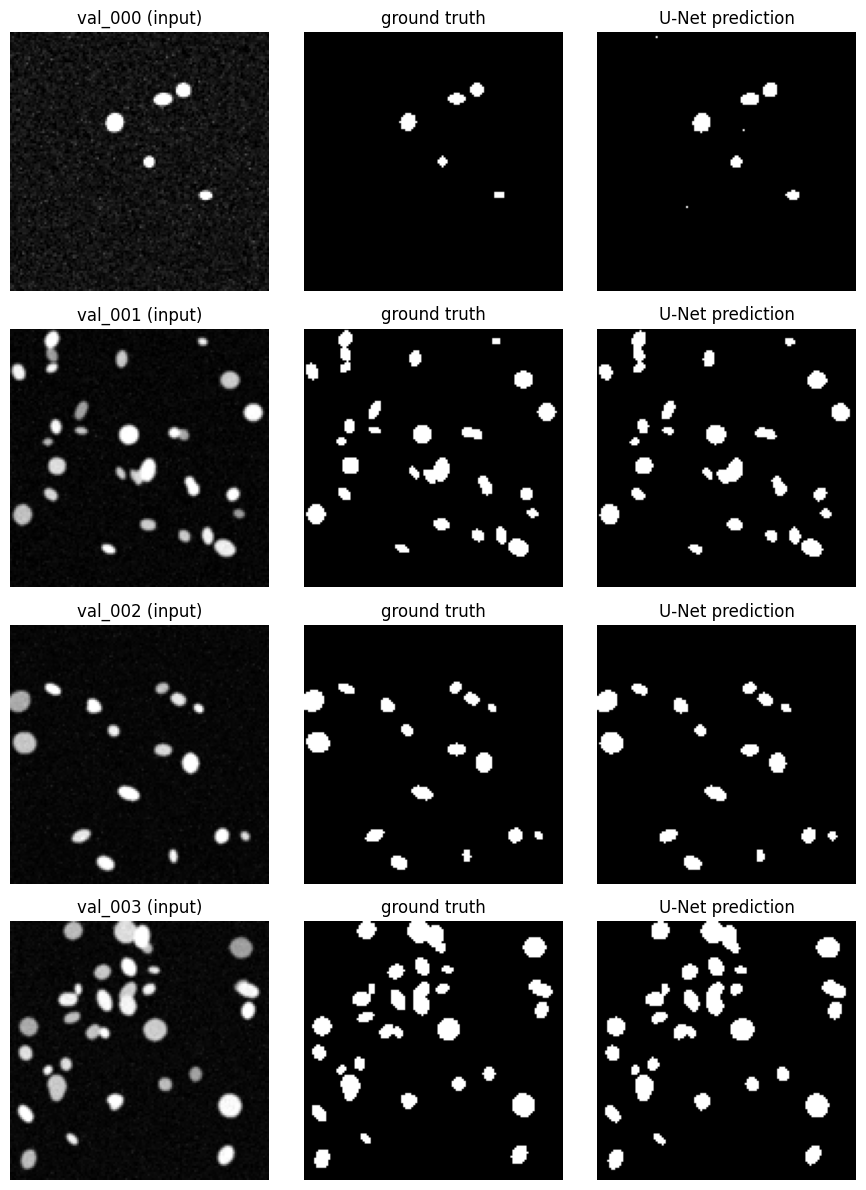

In [ ]:
# Input / ground truth / prediction panels for >=3 validation images
n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
with torch.no_grad():
    for i in range(n_show):
        x, y = val_ds[i]
        logits = model(x.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()
        axes[i, 0].imshow(x.squeeze().numpy(), cmap="gray"); axes[i, 0].set_title(f"{val_ds.img_paths[i].stem} (input)"); axes[i, 0].axis("off")
        axes[i, 1].imshow(y.squeeze().numpy(), cmap="gray"); axes[i, 1].set_title("ground truth"); axes[i, 1].axis("off")
        axes[i, 2].imshow(pred, cmap="gray"); axes[i, 2].set_title("U-Net prediction"); axes[i, 2].axis("off")
plt.tight_layout()
plt.savefig("fig_unet_panels.png", dpi=150)
plt.show()


### U-Net vs Otsu (report Question 2)

We saw in Task 2 that Otsu, applied to a **dense/clustered** image, undercounts objects badly
because touching nuclei merge into one connected component. It is worth checking whether this is a
limitation of thresholding specifically, or of *binary* segmentation in general — the cell below
checks how many connected components exist in the **ground-truth binary mask itself** on a
dense/clustered image, against the true instance count from the 16-bit instance labels.


In [ ]:
dense_id = metadata[metadata.density == "clustered"].iloc[0].image_id
split = metadata[metadata.image_id == dense_id].iloc[0].split
gt_mask = np.array(Image.open(DATA_ROOT / split / "masks" / f"{dense_id}.png")) > 127
gt_instances = np.array(Image.open(DATA_ROOT / split / "labels" / f"{dense_id}.png"))
binary_components = measure.label(gt_mask).max()
true_instances = len(np.unique(gt_instances)) - 1
print(f"{dense_id} (clustered): true instances={true_instances}, "
      f"connected components in the GROUND-TRUTH binary mask={binary_components}")
print("Even the ground-truth binary mask cannot separate touching nuclei by connected-component "
      "counting alone -- this is a property of binary segmentation, not a U-Net weakness. A fair "
      "comparison of U-Net vs Otsu is therefore on the mask/Dice level (where U-Net should win by "
      "learning texture/context Otsu cannot use), not on raw connected-component object counts.")


train_005 (clustered): true instances=52, connected components in the GROUND-TRUTH binary mask=17
Even the ground-truth binary mask cannot separate touching nuclei by connected-component counting alone -- this is a property of binary segmentation, not a U-Net weakness. A fair comparison of U-Net vs Otsu is therefore on the mask/Dice level (where U-Net should win by learning texture/context Otsu cannot use), not on raw connected-component object counts.


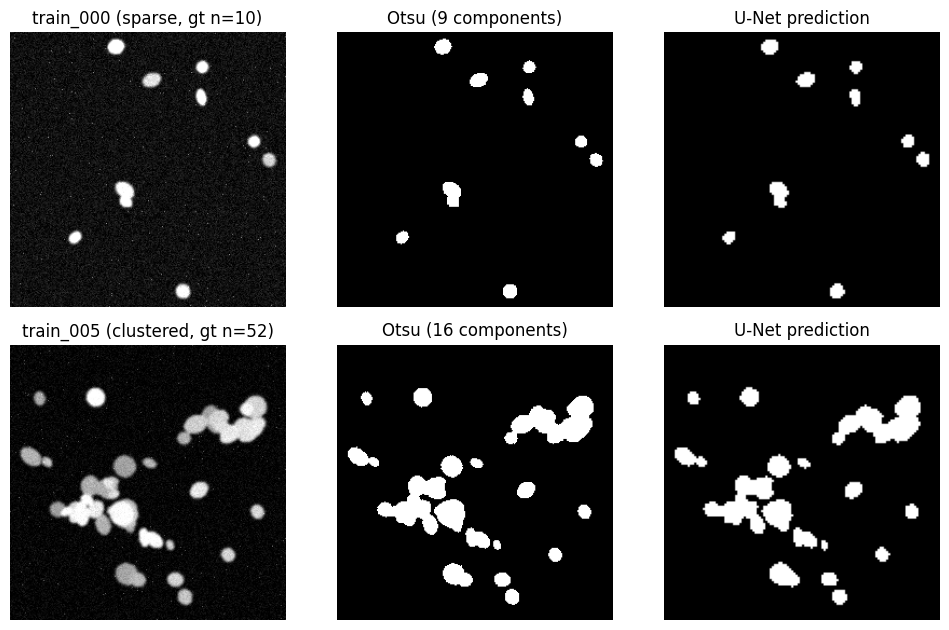

In [ ]:
# Compare Otsu vs U-Net masks directly on one sparse and one dense/clustered example
example_ids = [metadata[metadata.density == "sparse"].iloc[0].image_id,
               metadata[metadata.density == "clustered"].iloc[0].image_id]
fig, axes = plt.subplots(len(example_ids), 3, figsize=(10, 3.2 * len(example_ids)))
for i, img_id in enumerate(example_ids):
    row = metadata[metadata.image_id == img_id].iloc[0]
    gray = load_gray(DATA_ROOT / row.split / "images" / f"{img_id}.png")
    otsu_labels = otsu_segment(gray)
    gray_u = load_gray(DATA_ROOT / row.split / "images" / f"{img_id}.png", size=UNET_SIZE)
    with torch.no_grad():
        logits = model(torch.from_numpy(gray_u).unsqueeze(0).unsqueeze(0).to(device))
    unet_pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

    axes[i, 0].imshow(gray, cmap="gray"); axes[i, 0].set_title(f"{img_id} ({row.density}, gt n={row.n_objects})"); axes[i, 0].axis("off")
    axes[i, 1].imshow(otsu_labels > 0, cmap="gray"); axes[i, 1].set_title(f"Otsu ({otsu_labels.max()} components)"); axes[i, 1].axis("off")
    axes[i, 2].imshow(unet_pred, cmap="gray"); axes[i, 2].set_title("U-Net prediction"); axes[i, 2].axis("off")
plt.tight_layout()
plt.savefig("fig_otsu_vs_unet.png", dpi=150)
plt.show()


## Task 4 — Hybrid pipeline on the unseen test set

The full pipeline: U-Net mask -> `regionprops` feature table -> LLM structured JSON record
(`image_id`, `n_objects`, `mean_area`, `density_class`, `quality_flag`) -> one-paragraph narrative.
Run across all 12 unseen test images and aggregated into a CSV — this CSV, together with the JSON
records, is the auditable "source of truth" the narratives are checked against (report Question 4).

**Educational use only** — as in Lab 5, nothing here is validated for clinical use; a wrong
`quality_flag` or a confidently-worded narrative on a bad mask must not be trusted without a human
reviewer. This is illustrated directly by the robustness trace afterwards.


In [ ]:
def segment(img_np, size=UNET_SIZE):
    # Run the trained U-Net on a single image. Returns a binary mask at `size` resolution.
    if img_np.shape != (size, size):
        img_np = np.array(Image.fromarray((img_np * 255).astype(np.uint8)).resize((size, size))) / 255.0
        img_np = img_np.astype(np.float32)
    x = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
    pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()
    return pred.astype(np.uint8)


hybrid_prompt_template = '''You are summarising biomedical image-analysis results for a research
report. You will be given a textual summary of measurements taken from a segmented image -- you
have NOT seen the image itself.

Image ID: {image_id}
Summary: {summary}

Based ONLY on this summary, respond with ONLY a JSON object with exactly these fields:
{{
  "image_id": "{image_id}",
  "n_objects": <integer, copy exactly from the summary>,
  "mean_area": <number, copy exactly from the summary>,
  "density_class": "sparse" | "moderate" | "dense",
  "quality_flag": "ok" | "review_recommended" | "fail"
}}

Then, on a new line, write ONE short paragraph (2-3 sentences) describing the image in plain
language suitable for a research report.

Rules:
- Do not invent any number not present in the summary.
- Do not offer a diagnosis or clinical opinion.
- If the summary indicates zero or very few objects, or unusually large mean area (possible
  over-segmentation/merging), set quality_flag to "review_recommended".
'''


def full_pipeline(gray_img, image_name, model_name="llama3.2"):
    mask = segment(gray_img)
    gray_u = np.array(Image.fromarray((gray_img * 255).astype(np.uint8)).resize((UNET_SIZE, UNET_SIZE))) / 255.0
    df = extract_features(gray_u.astype(np.float32), measure.label(
        morphology.remove_small_objects(mask.astype(bool), min_size=8)))
    summary = summarise_features(df, image_name=image_name)
    prompt = hybrid_prompt_template.format(image_id=image_name, summary=summary)
    raw = chat(model=model_name, messages=[{"role": "user", "content": prompt}],
               options={"temperature": 0})["message"]["content"]
    record, narrative = split_json_and_prose(raw)
    record["image_id"] = image_name
    record["n_objects_measured"] = len(df)   # audit column: deterministic count vs the LLM's own
    record["mean_area_measured"] = float(df.area.mean()) if len(df) else 0.0
    record["narrative"] = narrative
    return record


final_records = []
for p in test_images_paths:
    gray = load_gray(p)
    rec = full_pipeline(gray, p.stem)
    final_records.append(rec)
    print(f"{p.stem}: n_objects(LLM)={rec.get('n_objects')} vs measured={rec['n_objects_measured']}")

df_final = pd.DataFrame(final_records)
df_final.to_csv("hybrid_pipeline_report.csv", index=False)
print(f"\nSaved hybrid_pipeline_report.csv with {len(df_final)} rows.")
df_final


test_000: n_objects(LLM)=8 vs measured=8
test_001: n_objects(LLM)=14 vs measured=14
test_002: n_objects(LLM)=25 vs measured=25
test_003: n_objects(LLM)=19 vs measured=19
test_004: n_objects(LLM)=43 vs measured=43
test_005: n_objects(LLM)=15 vs measured=15
test_006: n_objects(LLM)=8 vs measured=8
test_007: n_objects(LLM)=23 vs measured=23
test_008: n_objects(LLM)=22 vs measured=22
test_009: n_objects(LLM)=21 vs measured=21
test_010: n_objects(LLM)=35 vs measured=35
test_011: n_objects(LLM)=18 vs measured=18

Saved hybrid_pipeline_report.csv with 12 rows.


,image_id,n_objects,mean_area,density_class,quality_flag,n_objects_measured,mean_area_measured,narrative
0,test_000,8,52,sparse,ok,8,52.250000,The image contains a moderate number of object...
1,test_001,14,54,sparse,ok,14,53.928571,The image contains a moderate number of object...
2,test_002,25,59,sparse,ok,25,59.120000,The image contains a moderate number of object...
3,test_003,19,55,sparse,ok,19,54.736842,The image contains a moderate number of object...
4,test_004,43,83,moderate,ok,43,82.558140,The image contains a moderate density of objec...
5,test_005,15,110,sparse,ok,15,109.866667,The image contains a moderate number of object...
6,test_006,8,52,sparse,ok,8,52.125000,The image contains a moderate number of object...
7,test_007,23,53,sparse,ok,23,52.826087,The image contains a moderate number of object...
8,test_008,22,64,sparse,ok,22,63.590909,The image contains a moderate number of object...
9,test_009,21,47,sparse,ok,21,47.428571,The image contains a moderate number of object...


Compare the `n_objects` column (the LLM's own value, which it was told to copy from the
summary) against `n_objects_measured` (the deterministic pipeline value). They should agree
exactly. A row where they disagree is direct evidence of the LLM either drifting from its
instructions or, in the worst case, hallucinating a different number — precisely the failure mode
the audit column exists to catch.


## Extension — Robustness: tracing a corruption through the pipeline

The dataset ships pre-corrupted variants of two test images (`test_corrupted/`: heavy blur and low
contrast). We trace each corruption through every stage — mask, features, and (if Ollama is
running) the narrative — to find the **earliest** stage the problem becomes detectable.


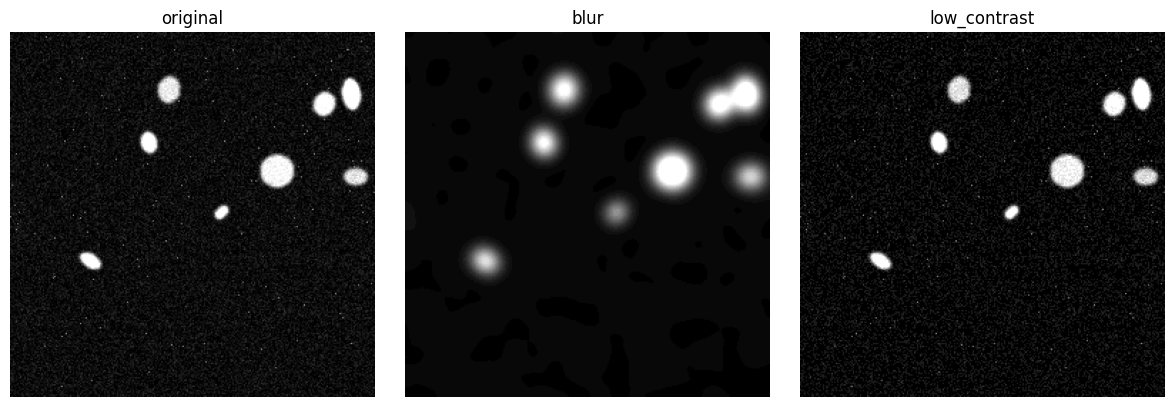

,variant,fg_pixels,n_objects,mean_area
0,original,418,8,52.250
1,blur,1197,7,171.000
2,low_contrast,411,8,51.375


In [ ]:
corrupted_dir = DATA_ROOT / "test_corrupted" / "images"
base_id = "test_000"
variants = {
    "original": DATA_ROOT / "test" / "images" / f"{base_id}.png",
    "blur": corrupted_dir / f"{base_id}_blur.png",
    "low_contrast": corrupted_dir / f"{base_id}_lowcontrast.png",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
rows = []
for ax, (name, path) in zip(axes, variants.items()):
    gray = load_gray(path)
    mask = segment(gray)
    gray_u = np.array(Image.fromarray((gray * 255).astype(np.uint8)).resize((UNET_SIZE, UNET_SIZE))) / 255.0
    df = extract_features(gray_u.astype(np.float32), measure.label(
        morphology.remove_small_objects(mask.astype(bool), min_size=8)))
    ax.imshow(gray, cmap="gray"); ax.set_title(name); ax.axis("off")
    rows.append({"variant": name, "fg_pixels": int(mask.sum()), "n_objects": len(df),
                 "mean_area": float(df.area.mean()) if len(df) else 0.0})
plt.tight_layout()
plt.savefig("fig_robustness_trace.png", dpi=150)
plt.show()

pd.DataFrame(rows)


Read the table above: on this image, **blur** measurably shifts `fg_pixels` and `mean_area`
upward (nuclei bleed together into fewer, larger blobs) — this is detectable at **Stage 1/2**
(segmentation/feature-extraction), before any LLM is ever called. **Low contrast**, by contrast,
barely shifts these numbers, because the percentile contrast-stretch applied during preprocessing
already normalises for it — an example of a design choice (Task 1's contrast stretch) accidentally
buying robustness against one corruption mode but not another. This is exactly the "earliest
detectable stage" analysis report Question 4/5 asks for: **cheap, deterministic checks at Stage 1/2
catch this corruption long before an LLM narrative would either notice it or, worse, describe it
confidently as normal.**

